# Глава 3. MovingAverageModel — скользящее среднее


## 1. Теория

### 1.1 Идея скользящего среднего

Прогноз — это среднее арифметическое последних `window` значений ряда, а не единственное последнее значение, как у `NaiveModel`:

$$\large y_t = \frac{1}{n}\sum_{i=1}^{n} y_{t-i}$$

где:
- $y_t$ — прогнозируемое значение в момент времени $t$;
- $n$ — размер окна (`window`) — сколько последних точек усредняем;
- $y_{t-i}$ — значение $i$ шагов назад от $t$: факт, если он ещё в пределах истории, или уже собственный прогноз модели (см. раздел 1.3).

При `window=1` формула вырождается в единственное последнее значение — то есть в прогноз `NaiveModel(lag=1)`. Это не приблизительное сходство, а буквальное совпадение прогнозов, проверишь сам в Задании 3.


### 1.2 Параметры и реализация

Исходник `etna/models/moving_average.py`:

```python
class MovingAverageModel(SeasonalMovingAverageModel):
    def __init__(self, window: int = 5):
        self.window = window
        super().__init__(window=window, seasonality=1)
```

**Параметры `MovingAverageModel`:**
- `window` *(int, по умолчанию `5`)* — размер окна усреднения; единственный параметр, который можно менять снаружи.
- `seasonality` — внутренний параметр родительского класса `SeasonalMovingAverageModel`, зафиксирован равным `1`, наружу не выведен.

**В отличие от `NaiveModel`:**
- нет параметра `lag` вообще — сдвиг относительно текущей точки не настраивается;
- `context_size = window * seasonality = window` (у `NaiveModel` было `context_size = lag`);
- прогноз — это среднее по `window` точкам, а не единственная точка.


### 1.3 Особенности

- **Рекурсия неизбежна, начиная со второго шага горизонта.** Формула рекурсивного прогноза одна для всей семьи `SeasonalMovingAverageModel`: `res[i] = res[i - context_size : i : seasonality].mean(axis=0)`. При `seasonality=1` шаг окна равен `1` — окно всегда прилегает вплотную к точке `i`, без «перепрыгивания». Значит окно для **второго** прогнозного шага (`i = context_size + 1`) обязательно захватывает первый прогноз (`res[context_size]`) — сколько бы ни было `window`, хоть `5`, хоть `50`. У `NaiveModel` правило `lag ≥ horizon` полностью защищает от рекурсии — у `MovingAverageModel` такого предохранителя нет вообще.
- `window` не защищает от рекурсии — он её **замедляет**.



## 2. Данные

Те же файлы, что и в тетради про `NaiveModel` (`local/data/`, в `.gitignore`):
- `units.csv` — 10 юнитов; для основной практики берём 2 из них (размер `10+`, typical + busier), для бонуса — все 10.
- `facts-by-date.csv` — дневные факты, 2022-01-01…2026-08-31.
- `forecasts-by-date.csv` — дневной прогноз текущей продовой модели, доступен за 2026-06-01…2026-08-31.
- `facts-by-hour.csv` / `forecasts-by-hour.csv` — почасовая гранулярность, если захочешь заглянуть вперёд.


In [2]:
import numpy as np
import pandas as pd

from etna.datasets import TSDataset
from etna.models import MovingAverageModel, NaiveModel
from etna.metrics import SMAPE, WAPE, MAPE, MAE
from etna.analysis import plot_forecast

from src.custom_logger import log_to_mlflow
from src.prod_metrics import bias, pooled

DATA_DIR = "../../local/data"


/Users/skv/projects-skv/study-etna/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Практика




### Задание 1. Синтетика: `window` гасит тренд, а не продолжает его

1. Сгенерируй синтетический ряд с чистым линейным трендом, без шума (например, `target = np.arange(...)`).
2. Выбери `HORIZON` и раздели ряд так, чтобы тестовый отрезок целиком лежал на продолжении тренда.
3. Обучи `MovingAverageModel` для маленького `window` (например, 2–3) и заметно большего горизонта (например, `window = 2 * HORIZON`), визуализируй оба прогноза через `plot_forecast`.
4. Вопросы:
    - продолжает ли прогноз тренд хоть при каком-то `window`?
    - что с ним происходит и с какой скоростью — при маленьком и при большом `window`?
    - почему это происходит?

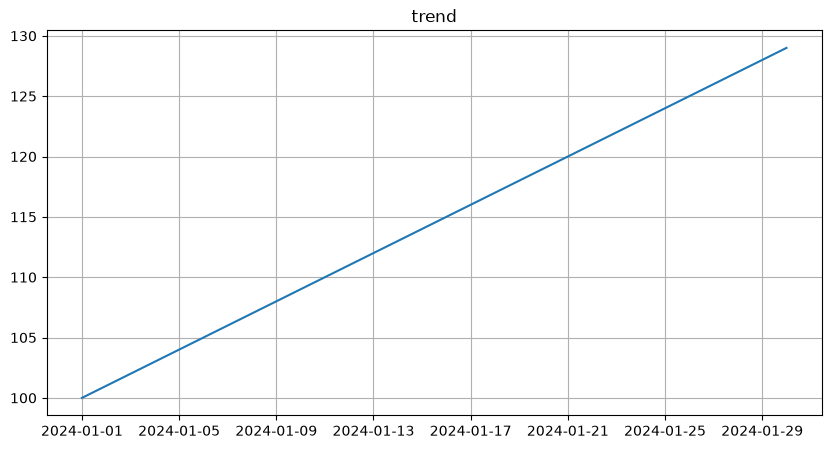

In [48]:
periods = 30
df = pd.DataFrame({
    "timestamp": pd.date_range("2024-01-01", periods=periods, freq="D"),
    "segment": "trend",
    "target": np.arange(periods, dtype=float) + 100.0,  # чистый линейный тренд, без шума
})
ts = TSDataset(TSDataset.to_dataset(df), freq="D")

ts.plot()

In [ ]:
def get_forecast(data, horizon, window, seasonality=1):

    train_ts, test_ts = data.train_test_split(test_size=horizon)

    # Магия ETNA
    model = MovingAverageModel(window=window)
    model.fit(train_ts)
    future = train_ts.make_future(future_steps=horizon, tail_steps=model.context_size)
    forecast = model.forecast(ts=future, prediction_size=horizon)


    # А теперь воспроизведем полученные результаты руками, что бы понимать.
    shift = window * seasonality

    # Выбираем target из обучающей выборки
    targets = train_ts.to_pandas(flatten=True)["target"]

    # Выбираем контекст модели из обучающей выборки. аналог make_future(tail_steps=model.context_size)
    series = targets[-shift:].values # array([108., 109.])

    # Создаем массив из shifts и горизонта прогноза заполненного нулями
    result = np.append(series, np.zeros(horizon))

    print(f"Заготовка: [{', '.join([f'{x:>.1f}' for x in result])}]\n")

    for i in range(shift, len(result)):
        # Номер шага прогноза
        step_num = i - shift + 1

        # Выделяем окно, по которому считаем среднее
        current_window = result[i - shift : i : seasonality]

        # индексы этого окна в result: < shift — ещё факт, >= shift — уже прогноз
        window_indices = range(i - shift, i, seasonality)
        n_facts = sum(1 for idx in window_indices if idx < shift)
        n_preds = sum(1 for idx in window_indices if idx >= shift)

        # Считаем само среднее
        result[i] = current_window.mean()

        # Делаем красиво
        window_str = ", ".join([f"{x:>.1f}" for x in current_window])

        print(
            f"Шаг {step_num:<2} | "
            f"Окно: [{window_str:<38}] | "
            f"Факты/Прогнозы: {n_facts}/{n_preds} | "
            f"Среднее: {result[i]:<10.2f} | "
            f"Позиция: {i:<2}"
        )

    plot_forecast(forecast_ts=forecast, test_ts=test_ts, train_ts=train_ts, n_train_samples=horizon)

Заготовка: [118.0, 119.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [118.0, 119.0                          ] | Факты/Прогнозы: 2/0 | Среднее: 118.50     | Позиция: 2 
Шаг 2  | Окно: [119.0, 118.5                          ] | Факты/Прогнозы: 1/1 | Среднее: 118.75     | Позиция: 3 
Шаг 3  | Окно: [118.5, 118.8                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.62     | Позиция: 4 
Шаг 4  | Окно: [118.8, 118.6                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.69     | Позиция: 5 
Шаг 5  | Окно: [118.6, 118.7                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.66     | Позиция: 6 
Шаг 6  | Окно: [118.7, 118.7                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.67     | Позиция: 7 
Шаг 7  | Окно: [118.7, 118.7                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.66     | Позиция: 8 
Шаг 8  | Окно: [118.7, 118.7                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.67     | Позиция: 9 
Шаг 9  | Ок

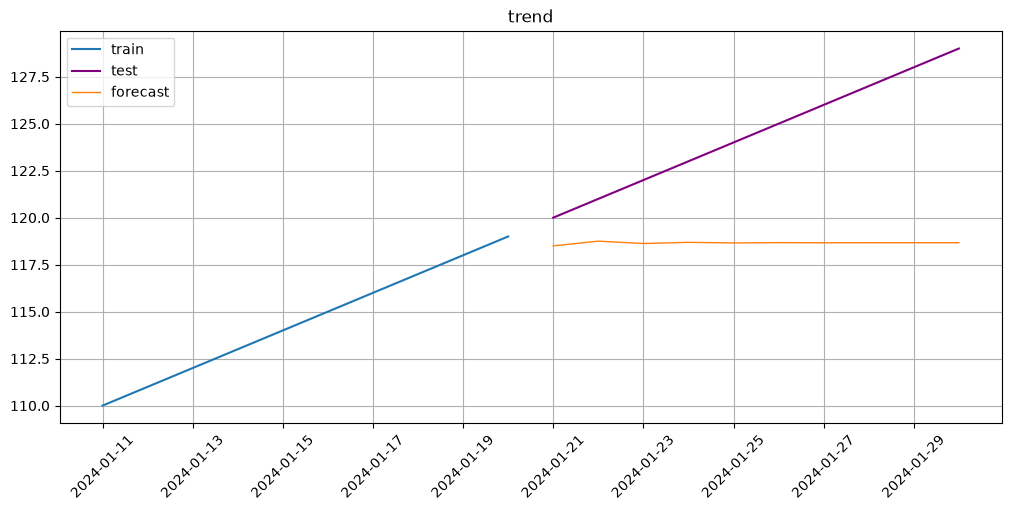

In [66]:
get_forecast(data=ts, horizon=10, window=2)

Заготовка: [115.0, 116.0, 117.0, 118.0, 119.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [115.0, 116.0, 117.0, 118.0, 119.0     ] | Факты/Прогнозы: 5/0 | Среднее: 117.00     | Позиция: 5 
Шаг 2  | Окно: [116.0, 117.0, 118.0, 119.0, 117.0     ] | Факты/Прогнозы: 4/1 | Среднее: 117.40     | Позиция: 6 
Шаг 3  | Окно: [117.0, 118.0, 119.0, 117.0, 117.4     ] | Факты/Прогнозы: 3/2 | Среднее: 117.68     | Позиция: 7 
Шаг 4  | Окно: [118.0, 119.0, 117.0, 117.4, 117.7     ] | Факты/Прогнозы: 2/3 | Среднее: 117.82     | Позиция: 8 
Шаг 5  | Окно: [119.0, 117.0, 117.4, 117.7, 117.8     ] | Факты/Прогнозы: 1/4 | Среднее: 117.78     | Позиция: 9 
Шаг 6  | Окно: [117.0, 117.4, 117.7, 117.8, 117.8     ] | Факты/Прогнозы: 0/5 | Среднее: 117.54     | Позиция: 10
Шаг 7  | Окно: [117.4, 117.7, 117.8, 117.8, 117.5     ] | Факты/Прогнозы: 0/5 | Среднее: 117.64     | Позиция: 11
Шаг 8  | Окно: [117.7, 117.8, 117.8, 117.5, 117.6     ] | Факты/Прогнозы: 0/5 | Среднее: 117.69     | По

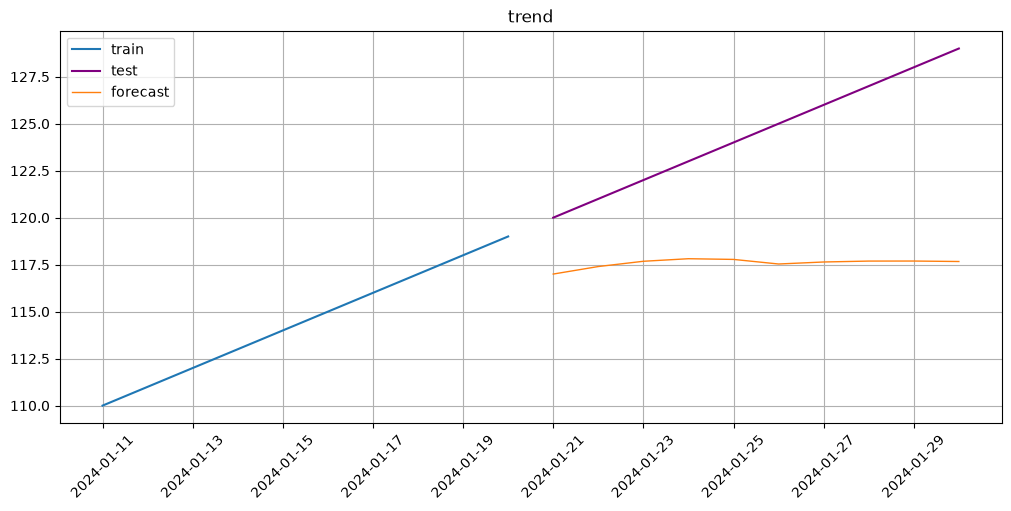

In [67]:
get_forecast(data=ts, horizon=10, window=5)

Заготовка: [110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0] | Факты/Прогнозы: 10/0 | Среднее: 114.50     | Позиция: 10
Шаг 2  | Окно: [111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 114.5] | Факты/Прогнозы: 9/1 | Среднее: 114.95     | Позиция: 11
Шаг 3  | Окно: [112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 114.5, 115.0] | Факты/Прогнозы: 8/2 | Среднее: 115.34     | Позиция: 12
Шаг 4  | Окно: [113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 114.5, 115.0, 115.3] | Факты/Прогнозы: 7/3 | Среднее: 115.68     | Позиция: 13
Шаг 5  | Окно: [114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 114.5, 115.0, 115.3, 115.7] | Факты/Прогнозы: 6/4 | Среднее: 115.95     | Позиция: 14
Шаг 6  | Окно: [115.0, 116.0, 117.0, 118.0, 119.0, 114.5, 115.0, 115.3, 115.7, 115.9] | Факты/Прогнозы: 5/5 | Среднее: 116.14     | Позиция: 15
Ша

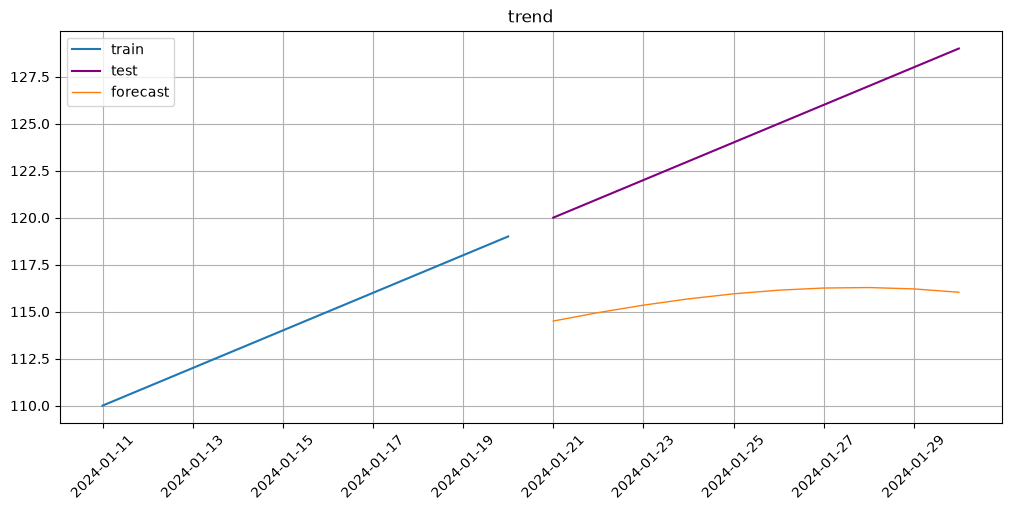

In [68]:
get_forecast(data=ts, horizon=10, window=10)

Заготовка: [100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0] | Факты/Прогнозы: 20/0 | Среднее: 109.50     | Позиция: 20
Шаг 2  | Окно: [101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 109.5] | Факты/Прогнозы: 19/1 | Среднее: 109.97     | Позиция: 21
Шаг 3  | Окно: [102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 109.5, 110.0] | Факты/Прогнозы: 18/2 | Среднее: 110.42     | Позиция: 22
Шаг 4  | Окно: [103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 109.5, 110.0, 110

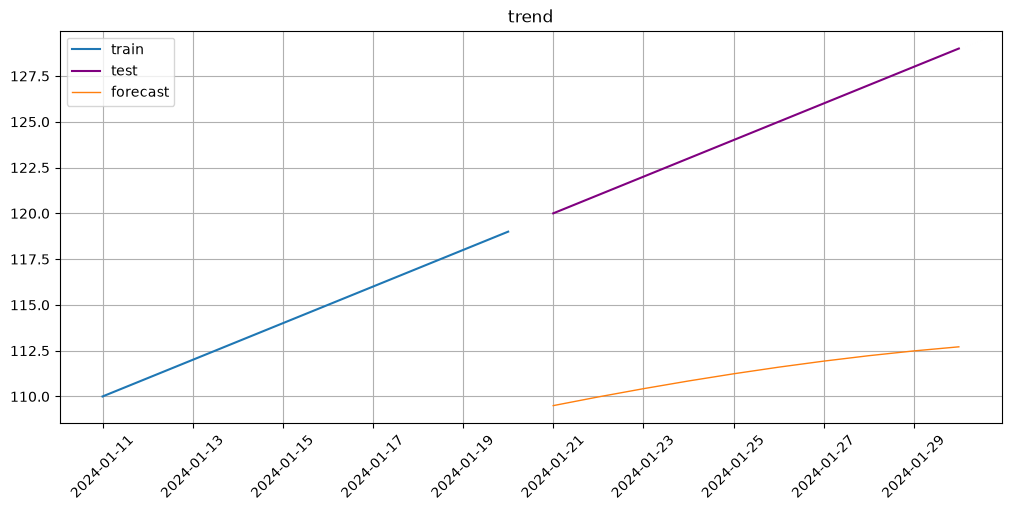

In [69]:
get_forecast(data=ts, horizon=10, window=20)

1. **Продолжает ли прогноз тренд хоть при каком-то window?** Нет, по-настоящему нет ни при каком window. При окне меньше горизонта тренд очень быстро затухает в константу. При окне горизонт×2 появляется только видимость направления — прогноз растёт в ту же сторону, что и тренд, но прогноз не продолжает тренд.

2. **Что с ним происходит и с какой скоростью — при маленьком и при большом window?** При маленьком окне прогноз быстро (за несколько шагов) затухает в плоскую линию. При большом окне направление тренда угадывается дольше, но сам прогноз всё равно систематически отстаёт от реального уровня и растёт медленнее, чем должен - это не сохранённый тренд, а его смягчённая, запаздывающая имитация. Наглядный пример того, как размер окна замедляет рекурсию, но не убирает её.

3. **Почему это происходит?** Потому что окно скользит по данным. Чтобы принять новое значение справа, оно обязано выбросить самое старое слева. Размер окна фиксирован и не может расти. Это происходит при любом window и даже, когда window равен длине всего трейна. Начиная со второго шага прогноза окно уже теряет один факт и замещает его одним прогнозом, и так на каждом следующем шаге вне зависимости от того, насколько большим было окно исходно.

### Задание 2. Загрузи данные по 2 юнитам размера `10+`

1. Прочитай `facts-by-date.csv` и `units.csv`, оставь только 2 юнита размера `10+` (typical + busier) — так же, как для `NaiveModel`.
2. Собери `TSDataset` (дневная частота), где `segment` = `MaskedUnitId`.
3. Посмотри на `ts.describe()`.
4. Построй `ts.plot()`.


### Задание 3. `window` и структурная рекурсия на одном юните

Возьми один юнит (например, самый «busier» из размера `10+`).

1. Выбери `HORIZON` (например, 14 дней) и раздели ряд на train/test.
2. Обучи `MovingAverageModel(window=1)`, сделай прогноз. Обучи для сравнения `NaiveModel(lag=1)` на том же train/test — прогнозы должны совпасть буквально (см. раздел 1.1). Проверь это на цифрах, а не на глаз.
3. Повтори для `window=3`, `window=7`, `window=HORIZON`, `window=HORIZON*2` — визуализируй каждый через `plot_forecast` и посмотри, как форма прогноза меняется с ростом `window`.
4. Как в книге и в `local/archive/002-MovingAverageModel.ipynb` — воспроизведи вручную (циклом по `numpy`-массиву, без вызова `model.forecast()`) шаги скользящего среднего для одного `window` и найди, на каком именно шаге в расчёт впервые попадает не факт, а прогноз самой модели.


### Задание 4. Выбираем `window` — общая картина по обоим юнитам

1. Обучи `MovingAverageModel` сразу на обоих сегментах для нескольких значений `window` (например, 1, 3, 5, 7, 14).
2. Для каждого `window` посчитай `SMAPE` — per-segment и агрегированно (`mode="macro"`).
3. Сравни — какой `window` даёт наименьшую агрегированную ошибку? Своими словами сформулируй, почему самый большой `window` не обязательно самый лучший (подсказка — раздел 1.3 и Задание 1).


### Задание 5. MovingAverage vs NaiveModel

1. Обучи лучший (по Заданию 4) `MovingAverageModel` с train, заканчивающимся перед 2026-06-01, получи прогноз на 2026-06-01…2026-08-31 для обоих юнитов.
2. Сопоставь по `MaskedUnitId` + дате: факт, прогноз `MovingAverageModel`, прогноз прода (`forecasts-by-date.csv`).
3. Посчитай `SMAPE` (по каждому юниту и агрегированно) отдельно для `MovingAverageModel` и отдельно для прода — на одних и тех же датах и юнитах.
4. Сделай вывод: скользящее среднее в целом хуже/лучше/сопоставимо с продом? Как это соотносится с результатом `NaiveModel` на тех же датах и юнитах?


### Бонус. Общая картина по всем 10 юнитам + логирование

1. Прогони лучший `window` сразу на всех 10 юнитах (используй `orders_df` из Задания 2 без фильтра по `unit_size`).
2. Посчитай весь набор метрик — `SMAPE`, `WAPE`, `MAPE`, `MAE`, `Bias` (через `src/prod_metrics.py`), per-segment и агрегированно.
3. Собери всё в одну таблицу `result` (`segment`/`unit_size`/`pick_reason`/`total_orders` + все метрики).
4. Залогируй через `log_to_mlflow(...)`, не забудь `tags={"chapter": "ch03", "units_scope": "all_10", "granularity": "day"}` — тогда в MLflow сможешь сравнить с `NaiveModel` прямо в таблице запусков.
